In [4]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np 

In [9]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2,random_state=23)

In [10]:
X.shape

(1000, 2)

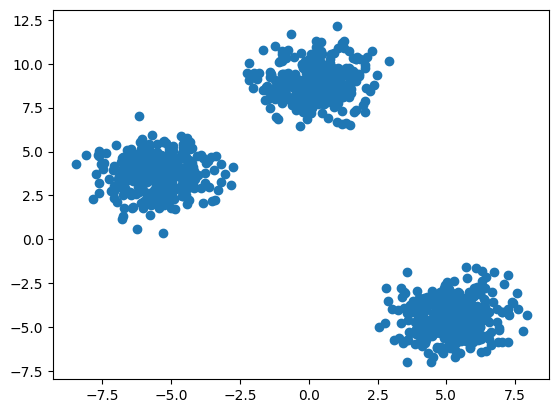

In [11]:
plt.scatter(X[:,0],X[:,1])

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=42)

In [15]:
from sklearn.cluster import KMeans

In [16]:
## Elbow Method (Manual)
wcss = []
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [17]:
wcss 

[34827.57682552021,
 7935.437286145418,
 1319.2730531585607,
 1170.8761156313992,
 1052.5431982069924,
 930.0528857750049,
 804.0136781919033,
 670.3946190477361,
 587.7908984894972,
 548.6728266239991]

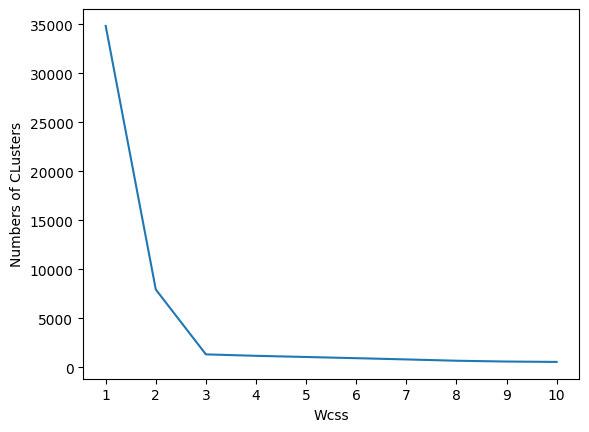

In [18]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.ylabel("Numbers of CLusters")
plt.xlabel('Wcss')
plt.show()

In [19]:
kmeans = KMeans(n_clusters=3,init='k-means++')

In [21]:
y_labels = kmeans.fit_predict(X_train)

In [24]:
y_test_labels=kmeans.predict(X_test)

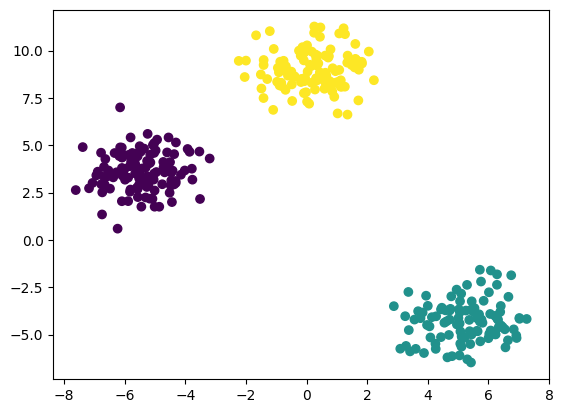

In [26]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_labels)

In [27]:
#autmated 
#using knee locator 

!pip install kneed

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.1.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
from kneed import KneeLocator

In [29]:
kl = KneeLocator(range(1,11) ,wcss,curve='convex',direction='decreasing')

In [31]:
print(kl.elbow)

3


In [32]:
## performamce metrics 

from sklearn.metrics import silhouette_score

In [34]:
sillhouette_coefficients=[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train)
    score = silhouette_score(X_train,kmeans.labels_)
    sillhouette_coefficients.append(score)

In [35]:
sillhouette_coefficients

[0.7281443868598331,
 0.8071181203797672,
 0.6355995834361389,
 0.5010701487047008,
 0.3383975138989348,
 0.31335544662626874,
 0.337983003011333,
 0.3467949947847857,
 0.3378687843416107]

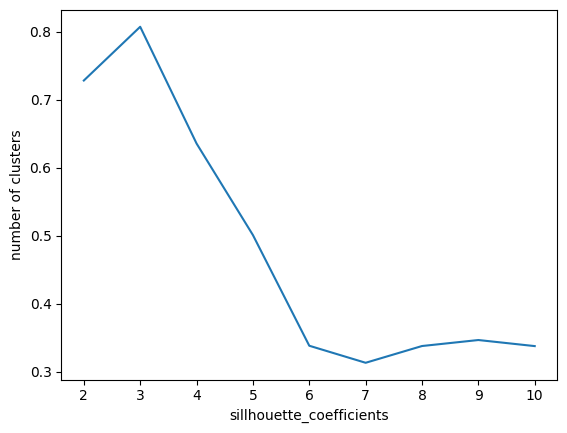

In [36]:
plt.plot(range(2,11),sillhouette_coefficients)
plt.xticks(range(2,11))
plt.ylabel('number of clusters')
plt.xlabel('sillhouette_coefficients')
plt.show()